In [2]:
import os
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import glob
from PIL import Image
import random

# Load Dataset

In [3]:
DATA_DIR = Path("../data")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

train_imgs = sorted(glob.glob(str(TRAIN_DIR / "image" / "*")))
train_masks = sorted(glob.glob(str(TRAIN_DIR / "mask" / "*")))
test_imgs = sorted(glob.glob(str(TEST_DIR / "image" / "*")))
test_masks = sorted(glob.glob(str(TEST_DIR / "mask" / "*")))

In [4]:
train_imgs[:5], train_masks[:5], test_imgs[:5], test_masks[:5]

(['../data/train/image/0.png',
  '../data/train/image/1.png',
  '../data/train/image/10.png',
  '../data/train/image/11.png',
  '../data/train/image/12.png'],
 ['../data/train/mask/0.png',
  '../data/train/mask/1.png',
  '../data/train/mask/10.png',
  '../data/train/mask/11.png',
  '../data/train/mask/12.png'],
 ['../data/test/image/0.png',
  '../data/test/image/1.png',
  '../data/test/image/10.png',
  '../data/test/image/11.png',
  '../data/test/image/12.png'],
 ['../data/test/mask/0.png',
  '../data/test/mask/1.png',
  '../data/test/mask/10.png',
  '../data/test/mask/11.png',
  '../data/test/mask/12.png'])

# Number of data samples

In [5]:
print(f"Number of training images: {len(train_imgs)}")
print(f"Number of training masks: {len(train_masks)}")
print(f"Number of testing images: {len(test_imgs)}")
print(f"Number of testing masks: {len(test_masks)}")

Number of training images: 80
Number of training masks: 80
Number of testing images: 20
Number of testing masks: 20


# Image dimension

In [6]:
sample_img = Image.open(train_imgs[0])
sample_mask = Image.open(train_masks[0])
print(f"Sample image size: {sample_img.size}, mode: {sample_img.mode}")
print(f"Sample mask size: {sample_mask.size}, mode: {sample_mask.mode}")

Sample image size: (512, 512), mode: RGB
Sample mask size: (512, 512), mode: L


In [7]:
size = sample_img.size
print(f"Expected image size: {size}")
for img_path in train_imgs + test_imgs + train_masks + test_masks:
    img = Image.open(img_path)
    if img.size != size:
        print(f"Image {img_path} has size {img.size}, expected {size}")

Expected image size: (512, 512)


# Missing data

In [8]:
for img_path in train_imgs + test_imgs + train_masks + test_masks:
    img = Image.open(img_path)
    if img is None:
        print(f"Missing data: {img_path}")

# Label

In [9]:
labels = set()
for mask_path in train_masks + test_masks:
    mask = Image.open(mask_path)
    labels.update(np.unique(np.array(mask)))
print(f"Unique labels in masks: {sorted(labels)}")
print(f"Number of unique labels: {len(labels)}")

Unique labels in masks: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20), np.uint8(21), np.uint8(22), np.uint8(23), np.uint8(24), np.uint8(25), np.uint8(26), np.uint8(27), np.uint8(28), np.uint8(29), np.uint8(30), np.uint8(31), np.uint8(32), np.uint8(33), np.uint8(34), np.uint8(35), np.uint8(36), np.uint8(37), np.uint8(38), np.uint8(39), np.uint8(40), np.uint8(41), np.uint8(42), np.uint8(43), np.uint8(44), np.uint8(45), np.uint8(46), np.uint8(47), np.uint8(48), np.uint8(49), np.uint8(50), np.uint8(51), np.uint8(52), np.uint8(53), np.uint8(54), np.uint8(55), np.uint8(56), np.uint8(57), np.uint8(58), np.uint8(59), np.uint8(60), np.uint8(61), np.uint8(62), np.uint8(63), np.uint8(64), np.uint8(65), np.uint8(66), np.uint8(67), np.uint8(68), np.uint8(69), np.ui

## Intensity range

In [10]:
min_pixel, max_pixel = 255, 0
for img_path in train_imgs + test_imgs:
    img = Image.open(img_path)
    img_array = np.array(img)
    min_pixel = min(min_pixel, img_array.min())
    max_pixel = max(max_pixel, img_array.max())
print(f"Pixel value range in images: min={min_pixel}, max={max_pixel}")

Pixel value range in images: min=0, max=255


In [11]:
min_pixel, max_pixel = 255, 0
for img_path in train_masks + test_masks:
    img = Image.open(img_path)
    img_array = np.array(img)
    min_pixel = min(min_pixel, img_array.min())
    max_pixel = max(max_pixel, img_array.max())
print(f"Pixel value range in images: min={min_pixel}, max={max_pixel}")

Pixel value range in images: min=0, max=255


# Visualize

In [12]:
def visualize(img_path, mask_path, n=5, threshold=128):
    idx = random.sample(range(len(img_path)), n)
    for i in idx:
        img = Image.open(img_path[i])
        mask = Image.open(mask_path[i])

        binary_mask = np.array(mask)
        binary_mask = (binary_mask > threshold).astype(np.uint8)

        overlay = np.array(img).copy()
        overlay[binary_mask == 1] = [255, 0, 0] # Red overlay on those blood vessels

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(img)
        axes[0].set_title("Original Image")
        axes[1].imshow(binary_mask, cmap='gray')
        axes[1].set_title("Mask")
        axes[2].imshow(overlay)
        axes[2].set_title("Overlay")
        for ax in axes:
            ax.axis('off')
        plt.suptitle(f'Sample {os.path.basename(img_path[i])}', fontsize=14)
        plt.tight_layout()
        plt.show()

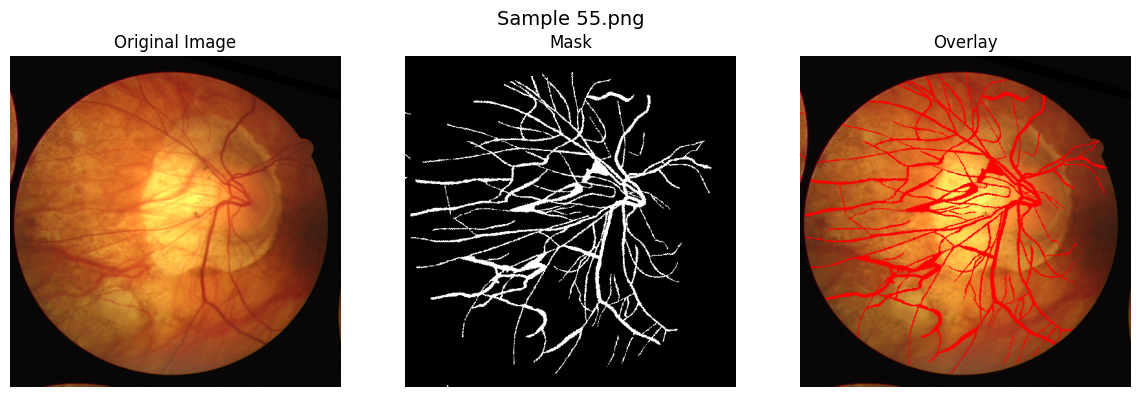

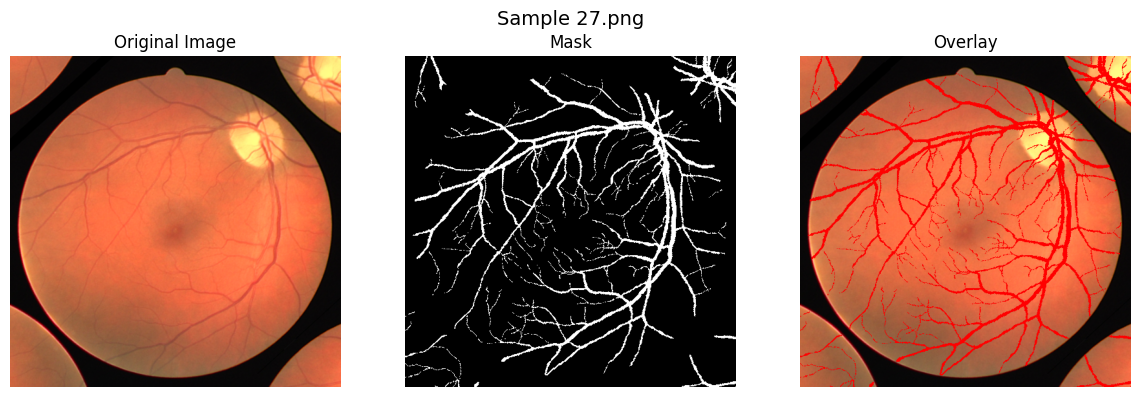

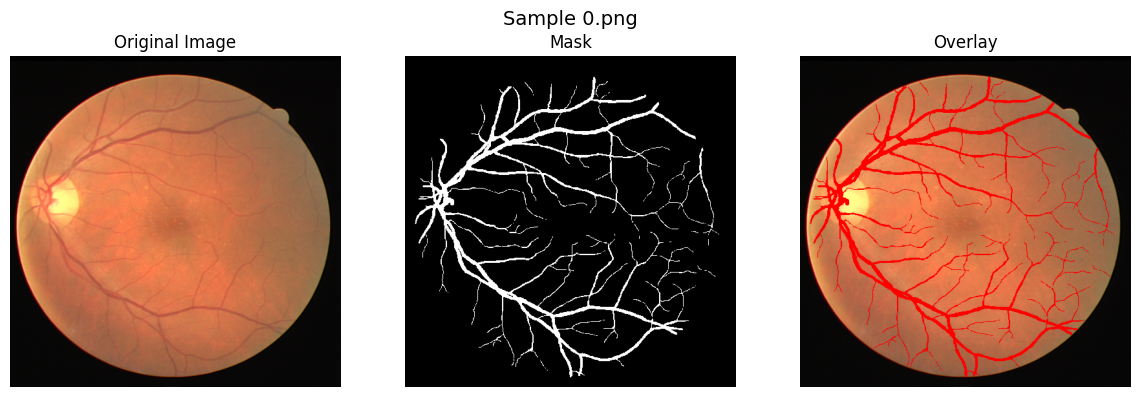

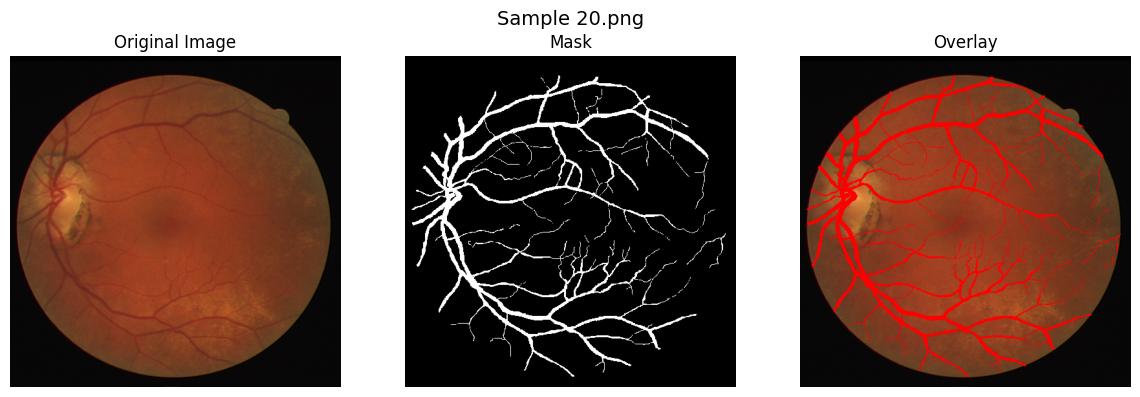

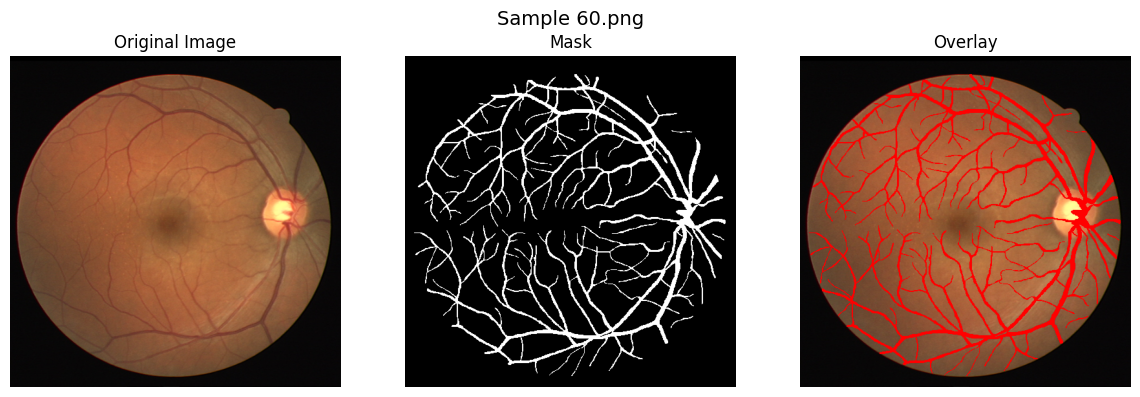

In [13]:
visualize(train_imgs, train_masks, n=5)

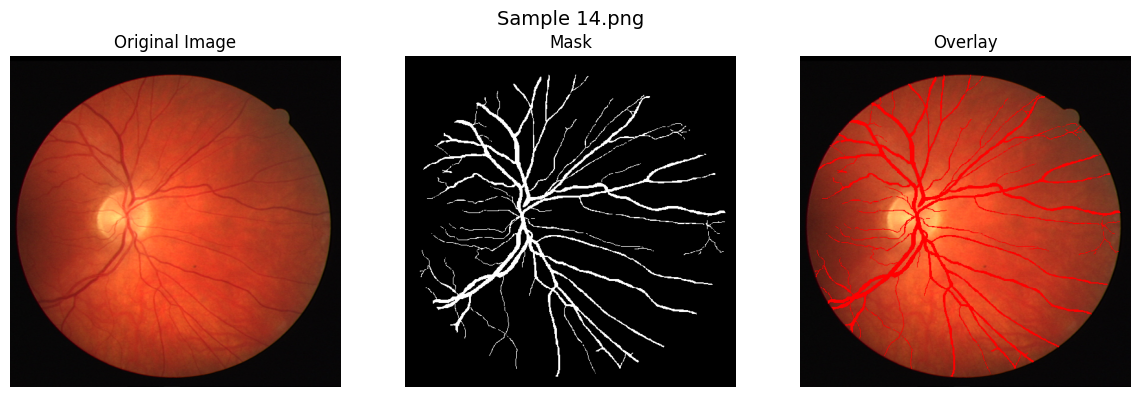

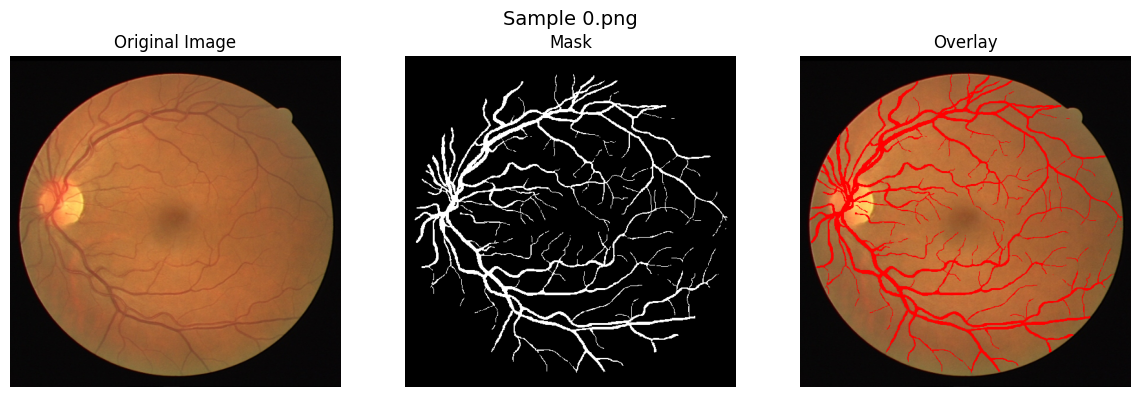

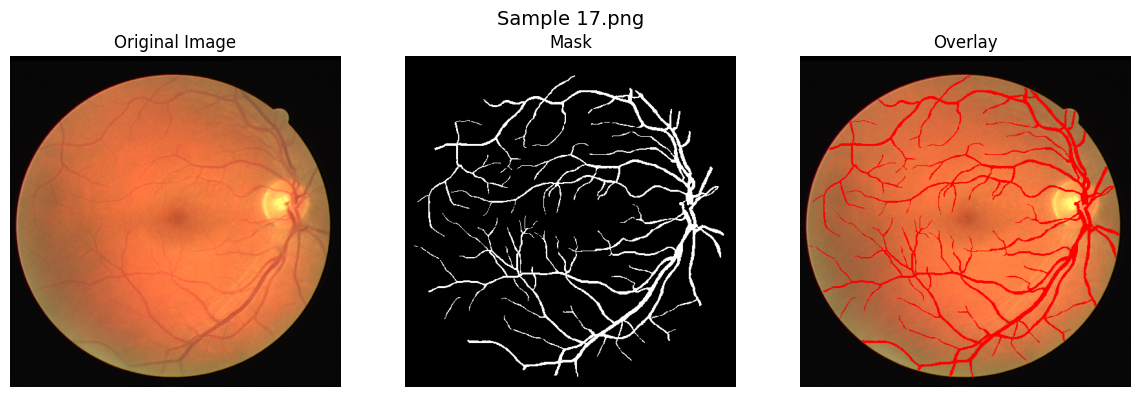

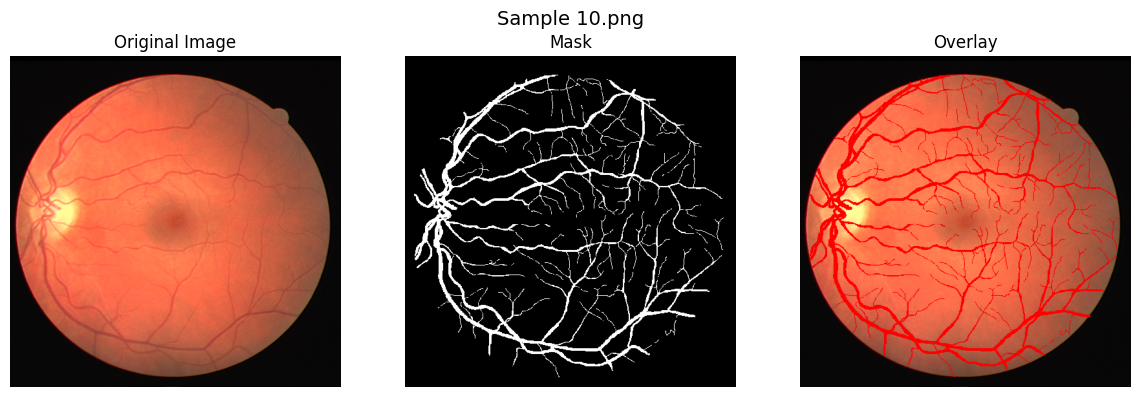

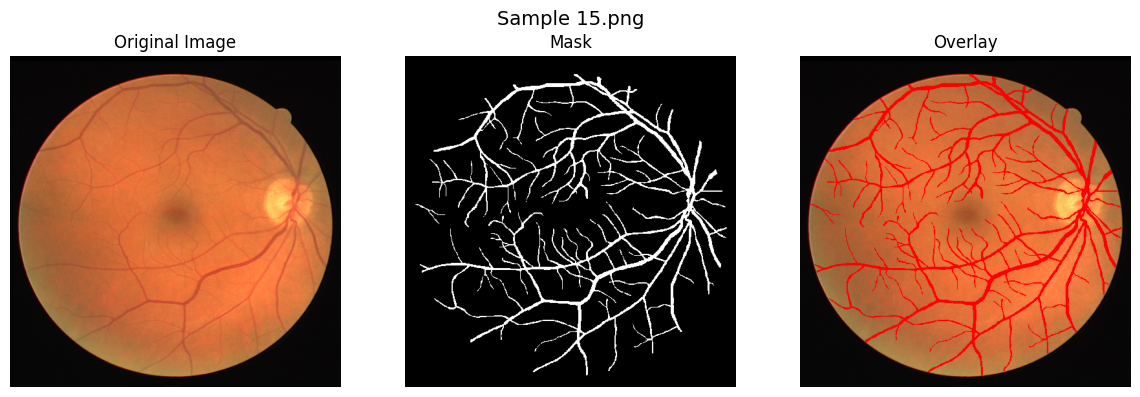

In [14]:
visualize(test_imgs, test_masks, n=5)

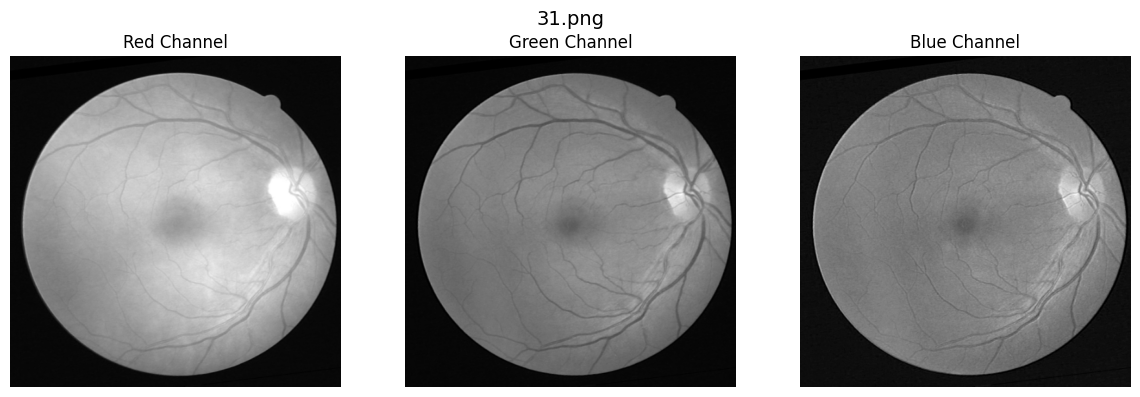

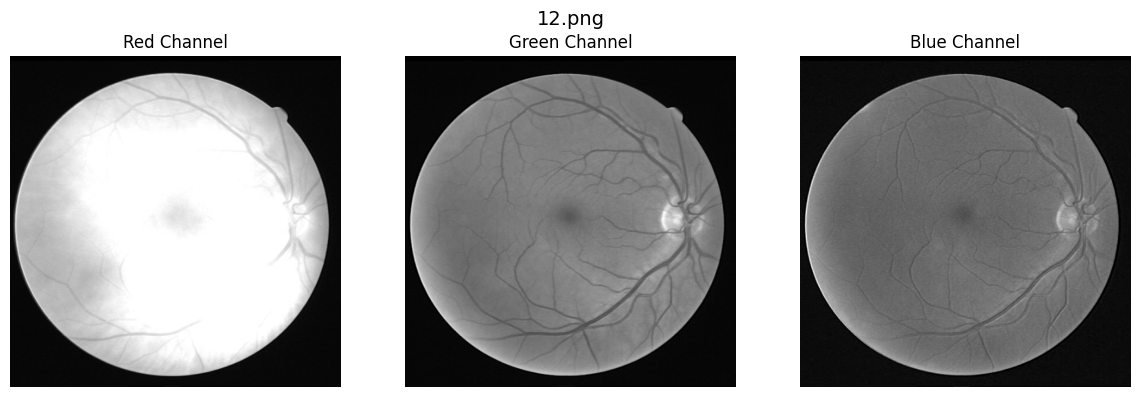

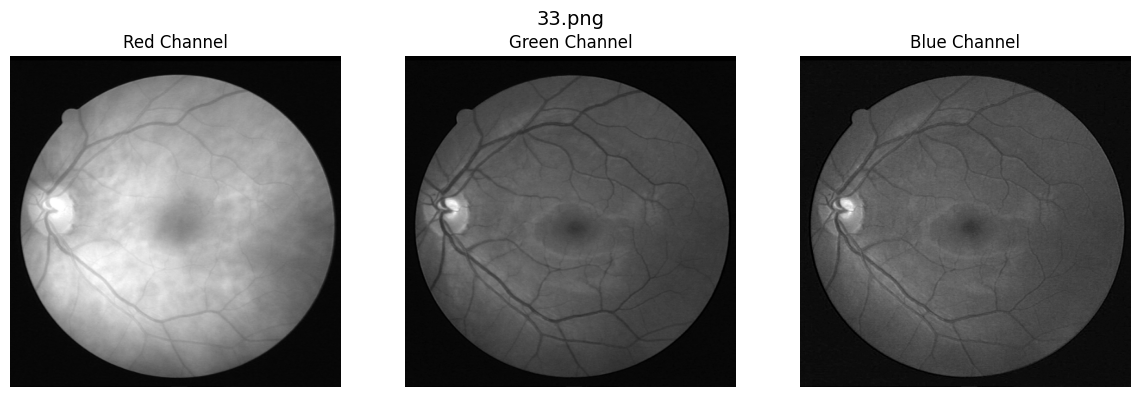

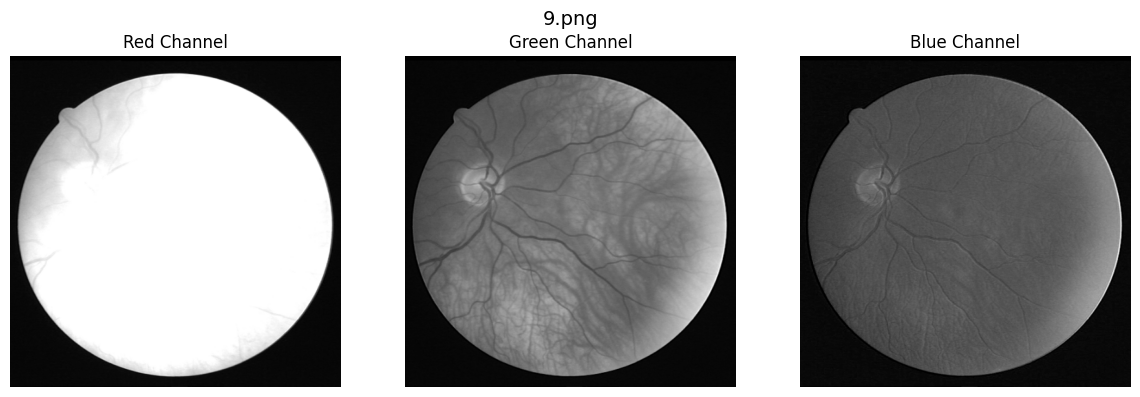

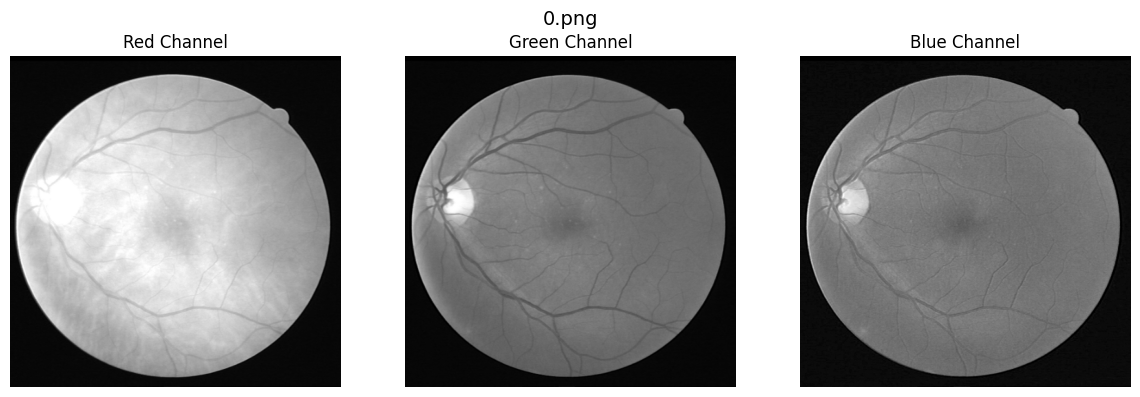

In [17]:
def visualize_channels(img_path, n=5):
    idx = random.sample(range(len(img_path)), n)
    for i in idx:
        img = Image.open(img_path[i])
        img_array = np.array(img)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(img_array[:, :, 0], cmap='gray')
        axes[0].set_title("Red Channel")
        axes[1].imshow(img_array[:, :, 1], cmap='gray')
        axes[1].set_title("Green Channel")
        axes[2].imshow(img_array[:, :, 2], cmap='gray')
        axes[2].set_title("Blue Channel")
        for ax in axes:
            ax.axis('off')
        plt.suptitle(f'{os.path.basename(img_path[i])}', fontsize=14)
        plt.tight_layout()
        plt.show()
visualize_channels(train_imgs, n=5)

In [ ]:
import cv2
from data.clahe import *

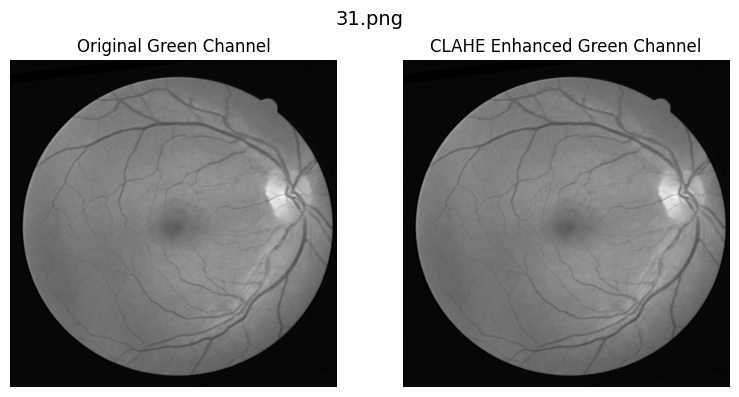

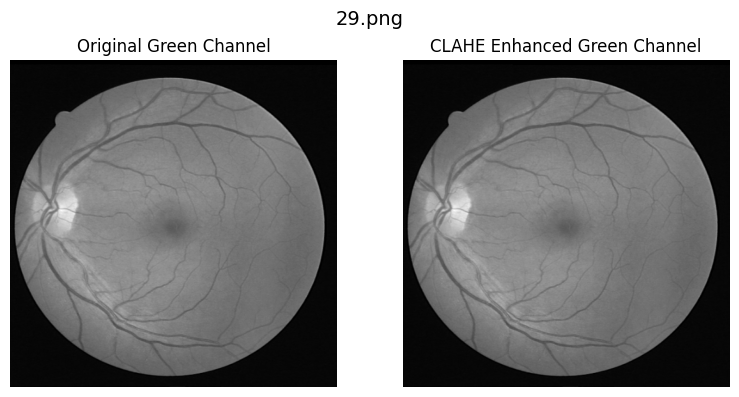

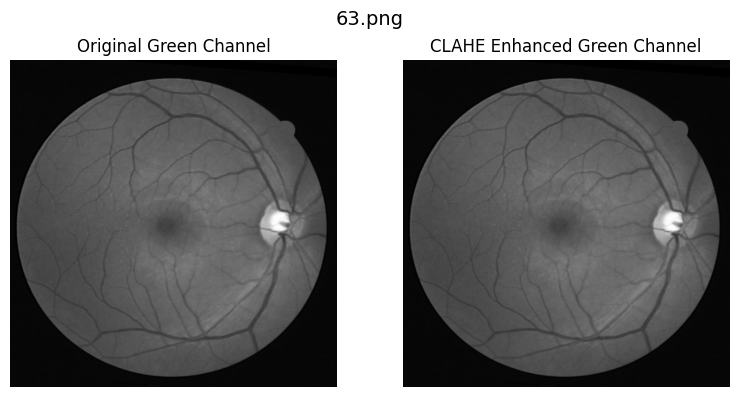

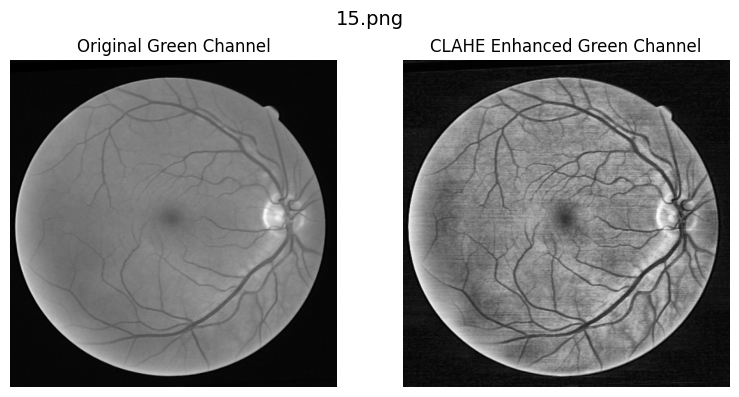

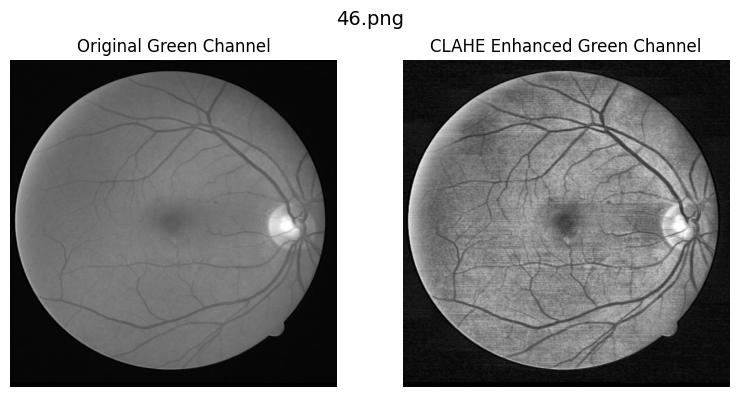

In [21]:
def visualize_clahe(img_path, n=5):
    idx = random.sample(range(len(img_path)), n)
    for i in idx:
        img = Image.open(img_path[i])
        img_array = np.array(img)

        green_channel = img_array[:, :, 1:2]
        clahe_green = apply_clahe(green_channel)

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(green_channel, cmap='gray')
        axes[0].set_title("Original Green Channel")
        axes[1].imshow(clahe_green, cmap='gray')
        axes[1].set_title("CLAHE Enhanced Green Channel")
        for ax in axes:
            ax.axis('off')
        plt.suptitle(f'{os.path.basename(img_path[i])}', fontsize=14)
        plt.tight_layout()
        plt.show()
visualize_clahe(train_imgs, n=5)